
# Enrich NBA Savant Shot Data — v2 Heuristic (Fixed NBA Corner Thresholds) + shotValue

This notebook augments an **NBA Savant** merged shots CSV (e.g., `nba_savant_2013_merged.csv`) with:
- `SHOT_CLOCK_APPROX` (copied from `shot_clock`)
- Contest heuristic using **action type**, **shot type**, **shot distance**, **(x, y)** location, and **SHOT_CLOCK_APPROX**
    - Applies the v2 heuristic using action_type, shot_type, shot_distance, x, y, and SHOT_CLOCK_APPROX, with:
    (x,y)-based corner-3-like inference (dataset-driven thresholds),
    catch-and-shoot corner 3s slightly more “open”,
    deep above-the-break 3s (≥27 ft) slightly more “open”,
    at-rim and mid-range nudges,
    late-clock (≤5s) “contested” nudge.
- **shotValue** derived from `shot_type` (`3PT Field Goal` → 3, `2PT Field Goal` → 2)

**Corner-3 detection now uses fixed NBA coordinates (tenths of feet):**
- Corner-like if **`abs(x) ≥ 220`** and **`y ≤ 50`**
- Otherwise, 3PT is treated as **above-the-break**.

## 1) Setup

In [10]:

# If needed:
# !pip install pandas matplotlib numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2) Load the Savant merged CSV

In [11]:

# Update to your actual file if different
IN_CSV = "raw_data/nba_savant_2014_merged.csv"
OUT_CSV = "enriched_data/nba_savant_2014_enriched_shots_v2.csv"

df = pd.read_csv(IN_CSV)
print(f"Loaded {len(df):,} rows from {IN_CSV}")
display(df.head(5))


Loaded 205,550 rows from raw_data/nba_savant_2014_merged.csv


,name,team_name,game_date,season,espn_player_id,team_id,espn_game_id,period,minutes_remaining,seconds_remaining,...,shot_distance,opponent,x,y,dribbles,touch_time,defender_name,defender_distance,shot_clock,team
0,Kevin Love,Cleveland Cavaliers,2014-10-31,2014,3449.0,1610612739,400578314.0,3,3,20,...,0,Chicago Bulls,-5,4,0,1.5,"Dunleavy, Mike",1.3,11.8,CLE
1,Timofey Mozgov,Cleveland Cavaliers,2015-04-10,2014,4298.0,1610612739,400579470.0,1,4,50,...,1,Boston Celtics,-10,3,0,0.7,"Zeller, Tyler",3.7,11.0,CLE
2,Tristan Thompson,Cleveland Cavaliers,2014-11-29,2014,6474.0,1610612739,400578530.0,3,11,11,...,0,Indiana Pacers,0,1,0,1.0,"Sloan, Donald",0.5,14.9,CLE
3,Tristan Thompson,Cleveland Cavaliers,2015-01-30,2014,6474.0,1610612739,400578992.0,2,0,2,...,0,Sacramento Kings,0,1,0,0.0,"Cousins, DeMarcus",2.6,0.0,CLE
4,LeBron James,Cleveland Cavaliers,2014-12-21,2014,1966.0,1610612739,400578693.0,4,10,11,...,0,Memphis Grizzlies,0,1,0,0.3,"Pondexter, Quincy",5.4,19.0,CLE


## 3) Heuristic v2 — contested/open classification (+ shotValue)

In [12]:

def classify_contest_savant_v2(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive contest_score/label/reasons using:
      - action_type, shot_type, shot_distance, x, y, SHOT_CLOCK_APPROX
    Enhancements:
      - Corner-3-like uses NBA fixed thresholds in tenths of feet:
          abs(x) >= 220 and y <= 50
      - Above-the-break 3s (not-corner) get deep-3 relief if distance >= 27 ft
      - Adds shotValue from shot_type (3 for 3PT, 2 for 2PT)
    """
    out = df.copy()

    # 0) SHOT_CLOCK_APPROX from 'shot_clock'
    if "shot_clock" in out.columns:
        out["SHOT_CLOCK_APPROX"] = pd.to_numeric(out["shot_clock"], errors="coerce")
        out["SHOT_CLOCK_SOURCE"] = np.where(out["SHOT_CLOCK_APPROX"].notna(), "from_savant_shot_clock", "missing_shot_clock")
    else:
        out["SHOT_CLOCK_APPROX"] = np.nan
        out["SHOT_CLOCK_SOURCE"] = "no_shot_clock_column"

    # Normalizer
    def norm(s): 
        return (str(s).strip().lower()) if pd.notna(s) else ""

    # Action keywords
    contested_like = {
        "step back", "pullup", "pull-up", "fadeaway", "turnaround",
        "driving", "running", "floating", "reverse", "hook"
    }
    open_like = {
        "catch and shoot", "catch-and-shoot", "spot up", "spot-up", "jump shot"
    }

    scores, labels, reasons = [], [], []

    for _, r in out.iterrows():
        score = 0
        why = []

        action = norm(r.get("action_type"))
        stype  = norm(r.get("shot_type"))

        # distance
        try:
            dist = float(r.get("shot_distance")) if pd.notna(r.get("shot_distance")) else np.nan
        except Exception:
            dist = np.nan

        # coords (expected in tenths of feet; e.g., corner ~ x≈±220..250, y≈0..50)
        try:
            rx = float(r.get("x"))
            ry = float(r.get("y"))
        except Exception:
            rx, ry = np.nan, np.nan

        is_3pt  = "3pt" in stype
        is_corner_like = False
        is_above_break = False

        if is_3pt and pd.notna(rx) and pd.notna(ry):
            if abs(rx) >= 220 and ry <= 50:
                is_corner_like = True
            else:
                is_above_break = True

        # 1) Action-type cues
        if any(k in action for k in contested_like):
            score += 2; why.append("action: contested-like")
        if any(k in action for k in open_like):
            score -= 1; why.append("action: open-like")

        # 2) Location / distance cues
        if pd.notna(dist):
            if dist <= 5:
                score += 1; why.append("location: at-rim/very close")
            if 8 <= dist <= 16:
                score += 1; why.append("location: mid-range")

            # Deep above-the-break 3s
            if is_3pt and is_above_break and dist >= 27:
                score -= 1; why.append("distance: deep above-break 3 (>=27ft)")

        # Corner-3 nuance
        if is_corner_like:
            why.append("coords: corner-3-like")
            if any(k in action for k in {"catch and shoot", "catch-and-shoot", "spot up", "spot-up"}):
                score -= 1; why.append("corner: catch-and-shoot")

        # 3) Shot clock pressure
        sc = r.get("SHOT_CLOCK_APPROX")
        try:
            sc_val = float(sc) if pd.notna(sc) else np.nan
        except Exception:
            sc_val = np.nan

        if pd.notna(sc_val) and sc_val <= 5:
            score += 1; why.append("clock: late-clock (<=5s)")

        # 4) Final label
        if score >= 2:
            label = "likely_contested"
        elif score == 1:
            label = "borderline"
        else:
            label = "likely_open"

        scores.append(score)
        labels.append(label)
        reasons.append(", ".join(why))

    out["contest_score"] = scores
    out["contest_label"] = labels
    out["contest_reasons"] = reasons

    # 5) Add shotValue based on shot_type
    def shot_value_from_type(stype: str):
        stype = stype.lower() if isinstance(stype, str) else ""
        if "3pt" in stype:
            return 3
        elif "2pt" in stype:
            return 2
        else:
            return np.nan

    out["shotValue"] = out["shot_type"].apply(shot_value_from_type)

    return out


## 4) Apply enrichment and save

In [13]:

enriched_v2 = classify_contest_savant_v2(df)

# Save
enriched_v2.to_csv(OUT_CSV, index=False)
print(f"Saved enriched Savant shots (v2) to {OUT_CSV}")

display(enriched_v2.head(12)[[
    "name","team_name","game_date","period","minutes_remaining","seconds_remaining",
    "action_type","shot_type","shot_distance","x","y","SHOT_CLOCK_APPROX",
    "shotValue","contest_score","contest_label","contest_reasons"
]])


Saved enriched Savant shots (v2) to enriched_data/nba_savant_2014_enriched_shots_v2.csv


,name,team_name,game_date,period,minutes_remaining,seconds_remaining,action_type,shot_type,shot_distance,x,y,SHOT_CLOCK_APPROX,shotValue,contest_score,contest_label,contest_reasons
0,Kevin Love,Cleveland Cavaliers,2014-10-31,3,3,20,Alley Oop Dunk Shot,2PT Field Goal,0,-5,4,11.8,2,1,borderline,location: at-rim/very close
1,Timofey Mozgov,Cleveland Cavaliers,2015-04-10,1,4,50,Alley Oop Dunk Shot,2PT Field Goal,1,-10,3,11.0,2,1,borderline,location: at-rim/very close
2,Tristan Thompson,Cleveland Cavaliers,2014-11-29,3,11,11,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,14.9,2,1,borderline,location: at-rim/very close
3,Tristan Thompson,Cleveland Cavaliers,2015-01-30,2,0,2,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,0.0,2,2,likely_contested,"location: at-rim/very close, clock: late-clock..."
4,LeBron James,Cleveland Cavaliers,2014-12-21,4,10,11,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,19.0,2,1,borderline,location: at-rim/very close
5,Kevin Love,Cleveland Cavaliers,2015-03-25,3,4,22,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,14.5,2,1,borderline,location: at-rim/very close
6,Kevin Love,Cleveland Cavaliers,2015-02-08,1,7,17,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,13.9,2,1,borderline,location: at-rim/very close
7,Timofey Mozgov,Cleveland Cavaliers,2015-03-25,2,7,29,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,15.0,2,1,borderline,location: at-rim/very close
8,Iman Shumpert,Cleveland Cavaliers,2015-02-08,2,8,14,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,13.0,2,1,borderline,location: at-rim/very close
9,Tristan Thompson,Cleveland Cavaliers,2015-01-21,3,2,36,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,8.0,2,1,borderline,location: at-rim/very close


## 5) Quick checks & simple plots

Contest label counts:


contest_label
likely_open         104513
likely_contested     51268
borderline           49769
Name: count, dtype: int64

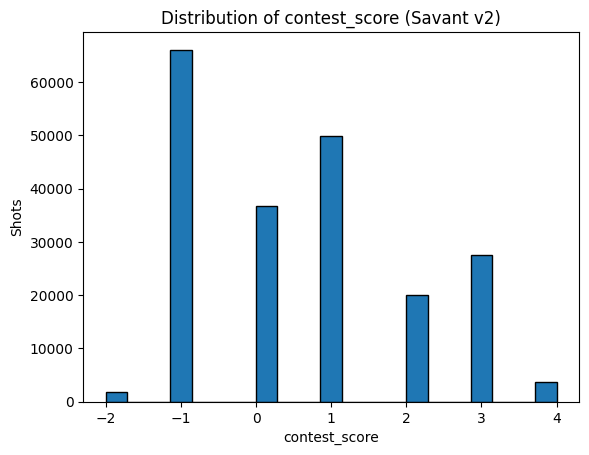

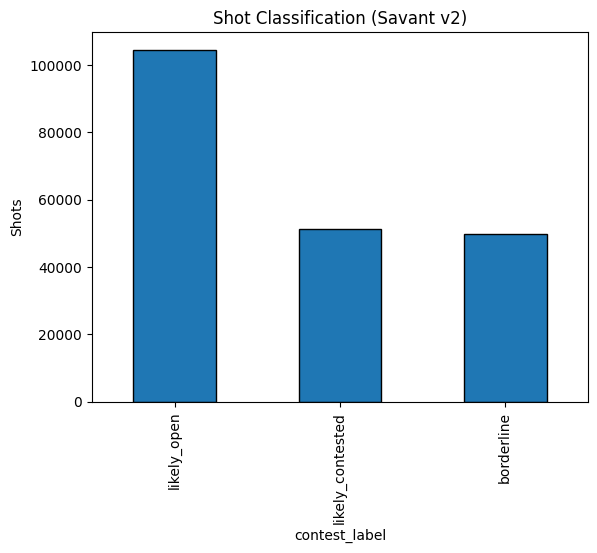

In [14]:

label_counts = enriched_v2["contest_label"].value_counts(dropna=False)
print("Contest label counts:")
display(label_counts)

plt.figure()
enriched_v2["contest_score"].dropna().astype(float).plot(kind="hist", bins=21, edgecolor="black")
plt.title("Distribution of contest_score (Savant v2)")
plt.xlabel("contest_score")
plt.ylabel("Shots")
plt.show()

plt.figure()
enriched_v2["contest_label"].value_counts().plot(kind="bar", edgecolor="black")
plt.title("Shot Classification (Savant v2)")
plt.xlabel("contest_label")
plt.ylabel("Shots")
plt.show()
